Ben's Innovative Feature is a Grad Cam Heatmap. This will highlight the areas of the original image that the model identified as real/spoofed.

Inturn, this provides insight in the exisiting blackbox models thus, users are able to gain an understanding of how the models think while potentially identifying areas where the model incorrectly predicts to refine in the training pipeline.

Grad-Cam Inspiration:
1. https://www.codetrade.io/blog/grad-cam-a-complete-guide-with-example/
2. https://www.kaggle.com/code/deanshalev/gradcam

In [41]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib import cm

In [42]:
# Configuration
IMG_SIZE = (224, 224)

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent

MODEL_PATH = PROJECT_DIR / "model" / "fasd_mobilenetv2_model.keras"

OUTPUT_DIR = CURRENT_DIR / "gradcam_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)


# Test images folder
RAW_KEY = "RAW_DATA_PATH="
TEST_FOLDER = "LCC_FASD_evaluation"


def find_project_root(start_path: Path | None = None) -> Path:
    current_path = start_path or Path.cwd()

    for path in [current_path, *current_path.parents]:
        if (path / ".gitignore").exists():
            return path

    raise FileNotFoundError("Could not find .gitignore")


def get_raw_data_path_from_gitignore() -> Path:
    project_root = find_project_root()
    gitignore_path = project_root / ".gitignore"

    lines = gitignore_path.read_text(encoding="utf-8").splitlines()

    raw_line = next(
        (line.strip() for line in lines if line.strip().startswith(RAW_KEY)),
        ""
    )

    raw_path = raw_line.removeprefix(RAW_KEY).strip()

    if not raw_path:
        raise ValueError("Missing RAW_DATA_PATH in .gitignore.")

    raw_path = Path(raw_path).expanduser()

    if not raw_path.is_absolute():
        raw_path = project_root / raw_path

    return raw_path.resolve()


def get_test_dir() -> Path:
    raw_data_dir = get_raw_data_path_from_gitignore()
    return raw_data_dir / TEST_FOLDER


# Get test folder first
test_dir = get_test_dir()

# Get all PNG images from the test folder
ALL_TEST_IMAGES = sorted(list(test_dir.rglob("*.png")))


# Confirm paths work
print("Current dir:", CURRENT_DIR)
print("Project dir:", PROJECT_DIR)
print("Model path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

print("\nTest dir:", test_dir)
print("Test exists:", test_dir.exists())
print("Total test images found:", len(ALL_TEST_IMAGES))


# Find 6 images:
# 2 true spoof predicted spoof
# 2 true real predicted real
# 1 true real predicted spoof
# 1 true spoof predicted real
def predict_image_fast(image_path, model, class_names):
    _, input_batch = load_image(image_path)

    predictions = model(input_batch, training=False).numpy()

    if predictions.shape[-1] == 1:
        score = float(predictions[0][0])
        pred_index = 1 if score >= 0.5 else 0
        confidence = score if pred_index == 1 else 1 - score
    else:
        pred_index = int(np.argmax(predictions[0]))
        confidence = float(np.max(predictions[0]))

    prediction_label = class_names[pred_index].lower()
    true_label = image_path.parent.name.lower()

    return true_label, prediction_label, confidence, predictions


def select_required_examples(image_paths, model, class_names, seed=None):
    rng = np.random.default_rng(seed)
    shuffled_paths = list(image_paths)
    rng.shuffle(shuffled_paths)

    selected = {
        "true_spoof_pred_spoof": [],
        "true_real_pred_real": [],
        "true_real_pred_spoof": [],
        "true_spoof_pred_real": []
    }

    required_counts = {
        "true_spoof_pred_spoof": 2,
        "true_real_pred_real": 2,
        "true_real_pred_spoof": 1,
        "true_spoof_pred_real": 1
    }

    for image_path in shuffled_paths:
        true_label, prediction_label, confidence, predictions = predict_image_fast(
            image_path=image_path,
            model=model,
            class_names=class_names
        )

        if true_label == "spoof" and prediction_label == "spoof":
            key = "true_spoof_pred_spoof"

        elif true_label == "real" and prediction_label == "real":
            key = "true_real_pred_real"

        elif true_label == "real" and prediction_label == "spoof":
            key = "true_real_pred_spoof"

        elif true_label == "spoof" and prediction_label == "real":
            key = "true_spoof_pred_real"

        else:
            continue

        if len(selected[key]) < required_counts[key]:
            selected[key].append(image_path)

        # Stop once all required categories have enough images
        if all(len(selected[key]) >= required_counts[key] for key in required_counts):
            break

    print("\nSelected examples summary:")
    for key in required_counts:
        print(f"{key}: {len(selected[key])}/{required_counts[key]}")

    selected_paths = []
    selected_paths.extend(selected["true_spoof_pred_spoof"])
    selected_paths.extend(selected["true_real_pred_real"])
    selected_paths.extend(selected["true_real_pred_spoof"])
    selected_paths.extend(selected["true_spoof_pred_real"])

    if len(selected_paths) < 6:
        print("\nWarning: Could not find all 6 requested cases.")
        print("This may happen if the model does not make those specific mistakes on the test set.")

    return selected_paths

Current dir: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\Bens_Innovative_Feature
Project dir: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2
Model path: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\model\fasd_mobilenetv2_model.keras
Model exists: True

Test dir: C:\Users\bbtnz\OneDrive\Documents\LCC_FASD\LCC_FASD_evaluation
Test exists: True
Total test images found: 7580


## Build Grad-cam Model

In [43]:
#Build Gradcam model - use just the anti-spoof conv final layer

def build_gradcam_model(model, layer_name="anti_spoof_conv"):

    gradcam_layer = model.get_layer(layer_name)

    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[gradcam_layer.output, model.output]
    )

    print("Using Grad-CAM layer:", gradcam_layer.name)
    print("Grad-CAM layer output shape:", gradcam_layer.output.shape)

    return grad_model

In [44]:
#Load image - Original Image for display + resized image for model output
def load_image(image_path):

    original_img = tf.keras.utils.load_img(image_path)
    original_array = tf.keras.utils.img_to_array(original_img)

    resized_img = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )
    resized_array = tf.keras.utils.img_to_array(resized_img)

    input_batch = np.expand_dims(resized_array, axis=0)

    return original_array, input_batch

In [45]:
#Create Grad-Cam heatmap - use gradient to determine which feature contributed strongly to predicted class

def make_gradcam_heatmap(input_batch, grad_model, class_index=None):

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(input_batch, training=False)

        if class_index is None:
            class_index = tf.argmax(predictions[0])

        class_score = predictions[:, class_index]

    gradients = tape.gradient(class_score, conv_output)

    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))

    conv_output = conv_output[0]

    heatmap = conv_output @ pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value.numpy() == 0:
        return heatmap.numpy(), predictions.numpy()

    heatmap = heatmap / max_value

    return heatmap.numpy(), predictions.numpy()

In [46]:
#Save Grad-Cam - original image with heatmap overlay

def create_gradcam_display_images(original_array, heatmap, alpha=0.4):
    original_uint8 = original_array.astype("uint8")
    h, w = original_uint8.shape[:2]

    #Resize heatmap using nearest neighbour so it stays pixelated
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        size=(h, w),
        method="nearest"
    ).numpy().squeeze()

    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    #Apply jet colormap
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]
    jet_heatmap_uint8 = np.uint8(jet_heatmap * 255)

    #Create overlay
    overlay_img = jet_heatmap_uint8 * alpha + original_uint8
    overlay_img = np.clip(overlay_img, 0, 255).astype("uint8")

    return original_uint8, jet_heatmap_uint8, overlay_img

In [47]:
#Run Prediction GradC-Cam with one image

def predict_with_gradcam(image_path, grad_model, class_names):

    if not image_path.exists():
        print(f"Image not found: {image_path}")
        return None

    original_array, input_batch = load_image(image_path)

    heatmap, predictions = make_gradcam_heatmap(
        input_batch=input_batch,
        grad_model=grad_model
    )

    if predictions.shape[-1] == 1:
        score = float(predictions[0][0])
        pred_index = 1 if score >= 0.5 else 0
        confidence = score if pred_index == 1 else 1 - score
    else:
        pred_index = int(np.argmax(predictions[0]))
        confidence = float(np.max(predictions[0]))

    prediction_label = class_names[pred_index]
    true_label = image_path.parent.name

    original_img, gradcam_img, overlay_img = create_gradcam_display_images(
        original_array=original_array,
        heatmap=heatmap
    )

    print("\nImage:", image_path.name)
    print("True label:", true_label)
    print("Raw prediction:", predictions)
    print(f"Detected as: {prediction_label}")
    print(f"Confidence: {confidence:.2%}")

    return {
        "image_path": image_path,
        "true_label": true_label,
        "prediction_label": prediction_label,
        "confidence": confidence,
        "original_img": original_img,
        "gradcam_img": gradcam_img,
        "overlay_img": overlay_img
    }

In [48]:
#Display gradcam results
def display_gradcam_grid(results):
    results = [result for result in results if result is not None]

    output_path = OUTPUT_DIR / "selected_test_gradcam_6x3.png"

    num_rows = len(results)

    fig, axes = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows))

    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, result in enumerate(results):
        axes[row, 0].imshow(result["original_img"])
        axes[row, 0].set_title(
            f"Original\nTrue: {result['true_label']}"
        )
        axes[row, 0].axis("off")

        axes[row, 1].imshow(result["gradcam_img"])
        axes[row, 1].set_title("Grad-CAM")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(result["overlay_img"])
        axes[row, 2].set_title(
            f"Overlay\nPred: {result['prediction_label']} ({result['confidence']:.2%})"
        )
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved Grad-CAM grid: {output_path}")

Using Grad-CAM layer: anti_spoof_conv
Grad-CAM layer output shape: (None, 7, 7, 32)

Selected examples summary:
true_spoof_pred_spoof: 2/2
true_real_pred_real: 2/2
true_real_pred_spoof: 1/1
true_spoof_pred_real: 1/1

Final selected images:
C:\Users\bbtnz\OneDrive\Documents\LCC_FASD\LCC_FASD_evaluation\spoof\spoof_5137.png
C:\Users\bbtnz\OneDrive\Documents\LCC_FASD\LCC_FASD_evaluation\spoof\spoof_4433.png
C:\Users\bbtnz\OneDrive\Documents\LCC_FASD\LCC_FASD_evaluation\real\real_250.png
C:\Users\bbtnz\OneDrive\Documents\LCC_FASD\LCC_FASD_evaluation\real\real_127.png
C:\Users\bbtnz\OneDrive\Documents\LCC_FASD\LCC_FASD_evaluation\real\real_86.png
C:\Users\bbtnz\OneDrive\Documents\LCC_FASD\LCC_FASD_evaluation\spoof\spoof_7163.png


C:\Users\bbtnz\AppData\Local\Temp\ipykernel_30808\2266542363.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")



Image: spoof_5137.png
True label: spoof
Raw prediction: [[0.00251183 0.99748814]]
Detected as: spoof
Confidence: 99.75%

Image: spoof_4433.png
True label: spoof
Raw prediction: [[0.00801299 0.991987  ]]
Detected as: spoof
Confidence: 99.20%

Image: real_250.png
True label: real
Raw prediction: [[0.8397522  0.16024777]]
Detected as: real
Confidence: 83.98%

Image: real_127.png
True label: real
Raw prediction: [[0.6129624  0.38703752]]
Detected as: real
Confidence: 61.30%

Image: real_86.png
True label: real
Raw prediction: [[0.48650882 0.51349115]]
Detected as: spoof
Confidence: 51.35%

Image: spoof_7163.png
True label: spoof
Raw prediction: [[0.6203623  0.37963778]]
Detected as: real
Confidence: 62.04%


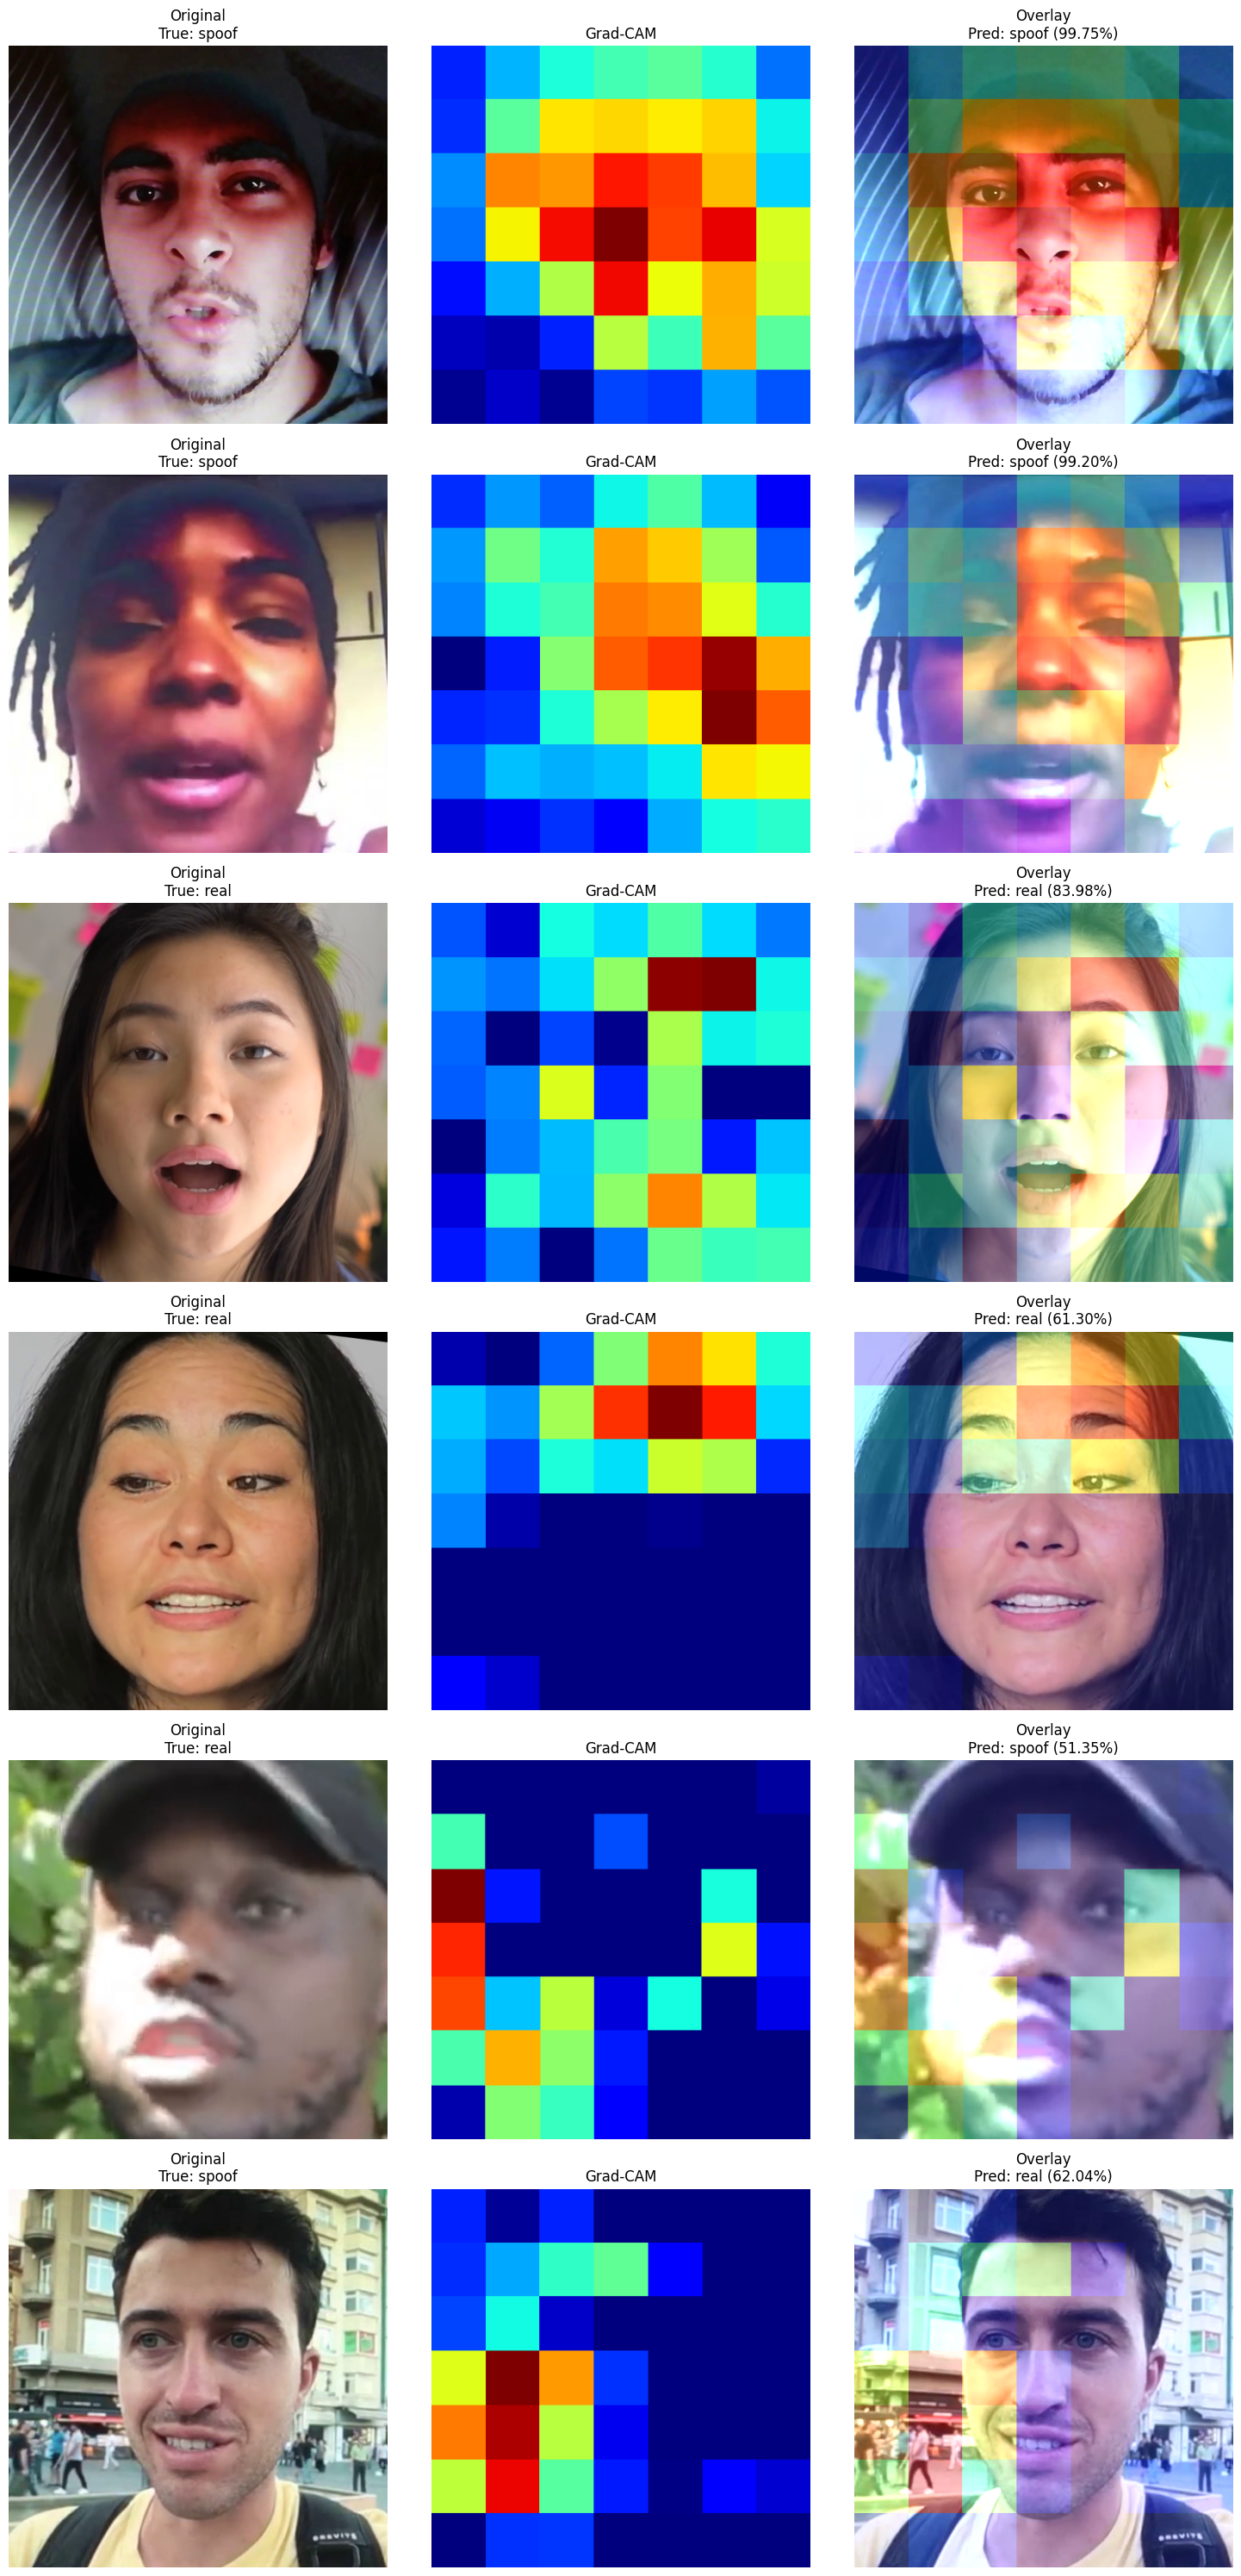

Saved Grad-CAM grid: c:\Users\bbtnz\OneDrive\Documents\GitHub\-Facial-Recognition-with-Emotion-and-Liveness\anti_spoofing_module_MobileNetV2\Bens_Innovative_Feature\gradcam_outputs\selected_test_gradcam_6x3.png


In [49]:
#Choose Mode
MODE = "report"  #Change when on live version

LIVE_IMAGE_PATH = CURRENT_DIR / "live_capture.png" #Rename this based on the live demo image


#Load model once
model = tf.keras.models.load_model(MODEL_PATH)

class_names = ["real", "spoof"]

grad_model = build_gradcam_model(
    model,
    layer_name="anti_spoof_conv"
)


#Select images based on mode
if MODE == "report":
    #Report mode: 2 correct spoof, 2 correct real, 1 real predicted spoof, 1 spoof predicted real
    SELECTED_IMAGE_PATHS = select_required_examples(
        image_paths=ALL_TEST_IMAGES,
        model=model,
        class_names=class_names,
        seed=None
    )

elif MODE == "live":
    #Live demo mode: only run Grad-CAM on one captured webcam image
    SELECTED_IMAGE_PATHS = [LIVE_IMAGE_PATH]

else:
    raise ValueError("MODE must be either 'report' or 'live'.")

print("\nFinal selected images:")
for path in SELECTED_IMAGE_PATHS:
    print(path)

#Run Grad-CAM
results = []

for image_path in SELECTED_IMAGE_PATHS:
    result = predict_with_gradcam(
        image_path=image_path,
        grad_model=grad_model,
        class_names=class_names
    )

    results.append(result)


# Display result grid
display_gradcam_grid(results)